# ECON 4370 / BANA 4373 — Homework 6 **ANSWER KEY**
## Text and Unstructured Data: From App Reviews to Business Intelligence

**CONFIDENTIAL — Instructor Use Only**  
Dr. Fidel González · Sam Houston State University · Spring 2026

---

> This answer key provides complete working code for every question, substantive
> written answers at the level expected for full credit, and **grading notes**
> (marked `📋 GRADING NOTE`) explaining what distinguishes an excellent answer
> from a passing one. Expected outputs are approximate — exact numbers depend
> on the fixed random seed (`np.random.seed(42)`) and the HuggingFace dataset
> version loaded at run time.

| Part | Topic | Points |
|------|-------|--------|
| 1 | Conceptual Questions | 20 |
| 2 | Data Pipeline | 15 |
| 3 | Text Analysis | 20 |
| 4 | Sentiment Scoring and Regression | 30 |
| 5 | Break the Analyzer | 15 |
| **Total** | | **100** |

---
## Setup


In [2]:
import subprocess, sys
for pkg in ['datasets', 'nltk', 'scikit-learn', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True)

import os, re
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from datasets import load_dataset
from matplotlib.lines import Line2D

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

for d in ['data_raw', 'data_clean', 'exports']:
    os.makedirs(d, exist_ok=True)

STOP_WORDS = set(stopwords.words('english'))
SIA        = SentimentIntensityAnalyzer()
NAVY, TEAL, GOLD, RED = '#1B3A6B', '#007B8A', '#C8A415', '#C0392B'
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('✓ Setup complete')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


✓ Setup complete


[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


---
# Part 1 — Conceptual Questions &nbsp; *(20 points)*

## Question 1 &nbsp; *(5 points)*

**TF-IDF vs. raw word frequency.**

a. Explain in your own words what TF-IDF measures and how it differs from a
   simple word frequency count.

b. Suppose the word *"app"* appears 500 times in 1-star reviews and 480 times
   in 5-star reviews. Would TF-IDF flag *"app"* as a distinctive word for either
   group? Why or why not?

c. Name one type of word that raw frequency over-weights and TF-IDF correctly discounts.

**Answer:**

**a.** TF-IDF stands for Term Frequency–Inverse Document Frequency. It scores each
word by how often it appears in a target group (TF) relative to how commonly it
appears across the entire corpus (IDF). A word that is frequent within 1-star reviews
but rare in 5-star reviews receives a high TF-IDF score for 1-star, signaling that it is
*distinctive* to that group. Raw frequency simply counts occurrences and has no
correction for words that are common everywhere. The key difference: raw frequency
tells you what people write a lot; TF-IDF tells you what makes one group's writing
different from another's.

**b.** No. TF-IDF would not flag "app" as distinctive for either group. The IDF
component penalizes words that appear in nearly every document. A word appearing 500
times in 1-star reviews and 480 times in 5-star reviews almost certainly appears in
the vast majority of all reviews — its IDF weight approaches zero, driving its
TF-IDF score to near zero regardless of raw frequency. Distinctiveness requires not
just high frequency in one group but *relative* rarity in the others.

**c.** Common topic words that appear across all review types — for example, *"app"*
itself, or *"phone"*, *"update"*, *"use"* in a mobile review corpus. These words
dominate raw frequency lists but carry no sentiment or group-discriminating signal.
Stopwords like *"the"* and *"is"* are removed by preprocessing, but even
content words that are universal across star levels are over-weighted by raw frequency
and correctly discounted by TF-IDF.

---
📋 **GRADING NOTE — Q1 (5 pts)**  
- **(a) 2 pts:** Award 2 for a correct explanation of both TF and IDF components and
  why IDF corrects for corpus-wide frequency. Award 1 if the student correctly
  identifies the distinction but conflates TF and IDF. Award 0 for tautologies
  ("TF-IDF measures term frequency times inverse document frequency" with no
  further explanation).  
- **(b) 2 pts:** Must correctly conclude NO and correctly cite the IDF mechanism.
  Award 1 if the conclusion is correct but the reasoning is vague.  
- **(c) 1 pt:** Any valid example of a content word (not a stopword) that raw
  frequency over-weights. Stopwords alone are not sufficient — the student
  should demonstrate understanding that even meaningful words can be non-distinctive.

## Question 2 &nbsp; *(5 points)*

**Three VADER failure modes.**

**Answer:**

| # | Review snippet | Human reads | VADER agrees? | Why |
|---|----------------|-------------|---------------|-----|
| 1 | *"Crashes every time I open it."* | Negative | Partially — VADER may score mildly negative. *"Crashes"* is not in VADER's core lexicon as a strong negative signal; it reads as a technical noun. | Weak negative signal for a domain idiom |
| 2 | *"Works fine I guess."* | Neutral / faint negative (lukewarm, resignation) | Disagrees — VADER scores positive. *"Works"* and *"fine"* are both positive in VADER's general lexicon. The hedge *"I guess"* carries the true ambivalence but VADER cannot weight it properly. | **Expectation language** |
| 3 | *"This update literally killed the app."* | Negative (the update broke it) | Disagrees or partially agrees — VADER flags *"killed"* as strongly negative but *"literally"* as an intensifier may partially offset. More likely: scores negative for the wrong reason, or scores it correctly but via the wrong token. | **Domain idiom** ("killed" = broke, in app context) |
| 4 | *"Finally fixed! Used to be terrible, now it's actually great."* | Positive (current state) | Partially disagrees — VADER sums all sentiment signals across the sentence. *"Terrible"* pulls the score down even though it describes the *past* state. VADER has no temporal model; it cannot distinguish "used to be X" from "is X". | **Negation scope / temporal context** |

**Named failure patterns:**
- **Snippet 2 — Expectation language:** Sentiment is carried by implication and hedging
  (*"I guess"*), not by emotionally charged keywords. VADER anchors on surface-positive
  words and misses the resignation.
- **Snippet 3 — Domain idiom:** *"Killed the app"* is a specialized tech-domain phrase
  meaning *broke* or *destroyed functionality*. In general English, *"killed"* is
  negative but its domain-specific meaning (a software regression) is not in VADER's
  lexicon as a product-failure signal.
- **Snippet 4 — Temporal context / negation scope:** VADER treats all clauses in a
  sentence as simultaneous. It cannot resolve that *"terrible"* describes a past state
  that has been corrected. The positive and negative signals partially cancel when they
  should not.

---
📋 **GRADING NOTE — Q2 (5 pts)**  
- **(Table) 3 pts:** 0.75 pts per row. Full credit requires a plausible human reading,
  a correct VADER prediction (agree or disagree), and a brief reason. The exact VADER
  score is not required — directional reasoning is sufficient.  
- **(Named patterns) 2 pts:** ~0.67 pts per pattern. Award full credit for any
  linguistically coherent label with a one-sentence justification. The exact terminology
  from the lecture is not required as long as the mechanism is correct.

## Question 3 &nbsp; *(5 points)*

**Measurement error and regression bias.**

**Answer:**

**a. Classical measurement error** is random noise in a variable that is
statistically independent of the true underlying signal and of all other variables
in the model. In OLS, classical measurement error in a *regressor* causes
**attenuation bias**: the estimated coefficient is biased toward zero. Intuitively,
noise in X obscures the true relationship between X and Y, making the association
appear weaker than it actually is. The standard error is also inflated, reducing
statistical power.

**b.** VADER's measurement error is almost certainly **non-classical (systematic)**.
The errors documented in Part 5 — domain idioms that VADER over-scores, irony and
understatement that VADER under-scores — are correlated with the content and style
of the review, which is itself correlated with the true satisfaction level (and
therefore the star rating). For example, 1-star reviews disproportionately contain
domain idioms like *"crashes"*, *"update broke"*, *"stopped working"* — exactly
the phrases VADER mis-scores. The mis-scoring rate is not random across star levels;
it is highest at the extremes (see Part 5, Q14).

**c.** With non-classical measurement error the direction of bias is less predictable
than with classical ME. Because VADER systematically over-estimates sentiment
for low-star reviews (false optimists) and under-estimates for high-star reviews
(false pessimists), the measured variable `vader_compound` is **compressed toward
the center** relative to the true sentiment. This compression is equivalent to
attenuation — the coefficient on `vader_compound` is biased **toward zero**,
understating how strongly sentiment predicts star ratings. The effect is
not uniform across star levels: the bias is largest at the 1-star and 5-star
extremes where VADER fails most, and smallest at 3 stars where VADER's
middling scores happen to match the middling outcome.

---
📋 **GRADING NOTE — Q3 (5 pts)**  
- **(a) 2 pts:** Must mention (i) measurement error is random/uncorrelated with true signal
  and (ii) the result is attenuation bias (coefficient biased toward zero). Award 1 if
  student correctly identifies attenuation but does not explain the independence condition.  
- **(b) 2 pts:** Must correctly conclude non-classical and cite a specific mechanism
  (e.g., VADER fails systematically at certain star levels or on certain phrase types).
  Award 1 if the conclusion is correct but the justification is generic
  ("VADER is not perfect"). Award 0 for classical.  
- **(c) 1 pt:** Must identify attenuation (toward zero) and ideally note the star-level
  asymmetry. Award 0.5 if they correctly say "toward zero" but do not connect to
  the compression mechanism.

## Question 4 &nbsp; *(5 points)*

**Business scenario: should you use VADER for this?**

**Answer:**

**a. Two statistical concerns:**

1. **Composition changes.** The average VADER score can shift because the *mix*
   of reviews changes, not because satisfaction changes. For example, if the app
   attracts a new user segment that writes in a more casual or ironic style
   (or in non-English languages that VADER handles poorly), the average compound
   score will move without any change in underlying satisfaction. Any month-to-month
   comparison is confounded by who is writing reviews.

2. **Systematic measurement error at the extremes.** VADER over-scores very
   negative reviews (domain idioms score near zero instead of strongly negative)
   and under-scores very positive reviews (irony and understatement). If the
   distribution of reviews shifts toward more 1-star or 5-star reviews — which
   is common after major updates or viral events — the KPI moves for a measurement
   reason, not a satisfaction reason.

**b. One alternative explanation for a 0.10-point VADER rise from January to February:**
A major app update in late January fixed a widely-reported crash bug. Users who
previously left 1-star crash reports stopped writing new reviews once the issue
was resolved, so the February review pool no longer contains the corpus of
technically-worded complaint reviews. VADER scores rise not because users are
genuinely happier but because the negatively-skewed crash-report vocabulary
dropped out of the sample.

**c. One additional piece of data:**  
The **raw star rating distribution** over the same period. If VADER compound
rises but the average star rating does not, the KPI is measuring noise, not
satisfaction. Star ratings are a direct, unambiguous signal that VADER is
attempting to proxy — comparing the two is the most basic sanity check
before presenting any sentiment-based KPI to a product team.

---
📋 **GRADING NOTE — Q4 (5 pts)**  
- **(a) 2 pts:** 1 pt per concern. Must be *statistical* concerns (not "VADER is
  imperfect" without elaboration). Award full credit for any two of: composition
  change, vocabulary drift after updates, measurement error at extremes, selection
  bias in who leaves reviews, survivorship bias. Award 0 for concerns that are
  not statistical (e.g., "users might lie").  
- **(b) 2 pts:** Must be a specific, concrete alternative that does not involve
  genuine satisfaction change. Award 1 for a plausible but vague answer
  ("the review pool changed"). Award 0 for "random variation".  
- **(c) 1 pt:** Any data source that provides an independent measure of satisfaction
  (star ratings, NPS scores, churn rate, support ticket volume). Award 0 for
  circular answers that reference more VADER analysis.

---
# Part 2 — Data Pipeline &nbsp; *(15 points)*

## Question 5 &nbsp; *(10 points)*

**Load, clean, and tokenize the app reviews.**

In [4]:
# ── Load app reviews ────────────────────────────────────────────────────────
print('Loading app reviews...')
ds     = load_dataset('app_reviews', split='train')
df_raw = ds.to_pandas()
df_raw = df_raw.rename(columns={'review': 'text', 'star': 'star'})
df_raw = df_raw[['text', 'star']].dropna().copy()
df_raw['star'] = df_raw['star'].astype(int)

np.random.seed(42)
frames = []
for star in range(1, 6):
    sub = df_raw[df_raw['star'] == star]
    frames.append(sub.sample(min(400, len(sub))))
df = pd.concat(frames).reset_index(drop=True).copy()

for star, label in [(1, '1-STAR'), (5, '5-STAR')]:
    ex = df[df['star'] == star].iloc[0]['text']
    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')
    print(str(ex)[:400])

df.to_csv('data_raw/app_reviews_raw.csv', index=False)
print(f'\n✓ Raw data saved. Shape: {df.shape}')

Loading app reviews...



  1-STAR
was working till update was gonna buy full version lucky me dont work any longer

  5-STAR
AWESOME Good graphics good controls good game!!! ?

✓ Raw data saved. Shape: (2000, 2)


In [6]:
# ── SOLUTION: clean_text ────────────────────────────────────────────────────
# Key decisions:
#   1. str(text) guards against non-string inputs (NaN, float, etc.)
#   2. [^a-z\s] removes digits, punctuation, emoji — keep only letters and spaces
#   3. Collapsing \s+ ensures single-space separation before strip()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ── SOLUTION: tokenize_and_filter ───────────────────────────────────────────
# Key decisions:
#   1. word_tokenize handles punctuation and contractions better than split()
#   2. STOP_WORDS is a set → O(1) lookup per token
#   3. len(t) >= 3 removes single-char tokens that survived cleaning (e.g. 'a')

def tokenize_and_filter(text):
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP_WORDS and len(t) >= 3]


# ── Apply ────────────────────────────────────────────────────────────────────
df['clean']       = df['text'].apply(clean_text)
df['tokens']      = df['clean'].apply(tokenize_and_filter)
df['token_count'] = df['tokens'].str.len()

print('Pipeline applied.')
print(f'\nOriginal (first 120 chars): {df["text"].iloc[0][:120]}')
print(f'Cleaned  (first 120 chars): {df["clean"].iloc[0][:120]}')
print(f'Tokens   (first 10):        {df["tokens"].iloc[0][:10]}')

Pipeline applied.

Original (first 120 chars): was working till update was gonna buy full version lucky me dont work any longer
Cleaned  (first 120 chars): was working till update was gonna buy full version lucky me dont work any longer
Tokens   (first 10):        ['working', 'till', 'update', 'gon', 'buy', 'full', 'version', 'lucky', 'dont', 'work']


📋 **GRADING NOTE — Q5 (10 pts)**  
- **(clean_text) 4 pts:** Must include lowercase (1), non-alpha removal with regex (2),
  and whitespace normalization (1). Common errors: using `replace()` instead of regex
  (loses -0.5 if it does not handle all punctuation), forgetting `str()` wrapper
  (loses -0.5 if NaN inputs would crash).  
- **(tokenize_and_filter) 4 pts:** Must use `word_tokenize` (2), filter stopwords (1),
  filter short tokens (1). Deduct -1 if student uses `str.split()` instead of
  `word_tokenize` — the distinction matters for contractions and punctuation.  
- **(Apply + output) 2 pts:** Pipeline applied correctly to all three columns, print
  statement shows sensible output. Deduct -1 if `token_count` column is missing.

## Question 6 &nbsp; *(5 points)*

**Describe the dataset.**

In [8]:
print(f'Total reviews: {len(df):,}')
print(f'\nReviews per star rating:')
print(df['star'].value_counts().sort_index().to_string())
print(f'\nReview length (words, raw text):')
print(df['text'].str.split().str.len().describe().round(1).to_string())
print(f'\nToken count after cleaning:')
print(df['token_count'].describe().round(1).to_string())

Total reviews: 2,000

Reviews per star rating:
star
1    400
2    400
3    400
4    400
5    400

Review length (words, raw text):
count    2000.0
mean       14.4
std        20.2
min         1.0
25%         3.0
50%         7.0
75%        19.0
max       422.0

Token count after cleaning:
count    2000.0
mean        7.6
std        10.1
min         0.0
25%         2.0
50%         4.0
75%        10.0
max       198.0


**Q6 written response:**

**a.** App reviews are considerably shorter than IMDB movie reviews (which averaged
~230 words) and shorter than Yelp restaurant reviews (~100 words). App reviews
typically average 20–50 words per review. The brevity reflects the medium:
mobile users write app reviews on their phones, often immediately after a frustrating
or delightful experience, with little deliberation. Movie and restaurant reviews
are written at leisure with more narrative intent. Shorter reviews are also
more likely to rely on condensed, idiomatic expressions — exactly the kind of
language VADER handles poorly.

**b.** The cleaning step typically removes 30–50% of tokens (stopwords + short tokens).
This fraction is roughly consistent with what we saw for IMDB and Yelp. The
proportion may feel high, but stopwords and very short tokens carry essentially no
sentiment signal and considerable noise. Removing them improves both the quality
of TF-IDF scores and the speed of downstream processing.

**c.** *(Answer depends on the actual reviews sampled — example answer)*  
In the 1-star reviews, the phrase *"stopped working after update"* appears frequently.
VADER would likely score *"working"* as a positive signal and *"stopped"* as a weak
negative, missing the compound meaning that the update broke the app. This is a
domain idiom failure: the phrase signals product failure through context rather
than through individually charged keywords.

---
📋 **GRADING NOTE — Q6 (5 pts)**  
- **(a) 2 pts:** Must make a specific comparison to a lecture corpus (IMDB or Yelp)
  and offer a plausible explanation for the difference. Award 1 for a correct
  comparison with no explanation.  
- **(b) 2 pts:** Must report an approximate percentage and offer a reason.
  Award 1 for a reasonable percentage with no interpretation.  
- **(c) 1 pt:** Must name a *specific* word or phrase from the actual data and
  explain the VADER failure mechanism. Award 0 for generic answers
  ("VADER might fail on technical words").

---
# Part 3 — Text Analysis &nbsp; *(20 points)*

## Question 7 &nbsp; *(10 points)*

**Word frequency at the rating extremes.**

✏️ **Prior (model answer):**

1-star top words: *crash, fix, update, broken, slow*  
5-star top words: *love, great, amazing, best, easy*  

📋 Prior-write is not graded on correctness — only on *presence* (it must be filled in
before the code cell output appears). Dock professionalism points if prior is empty.

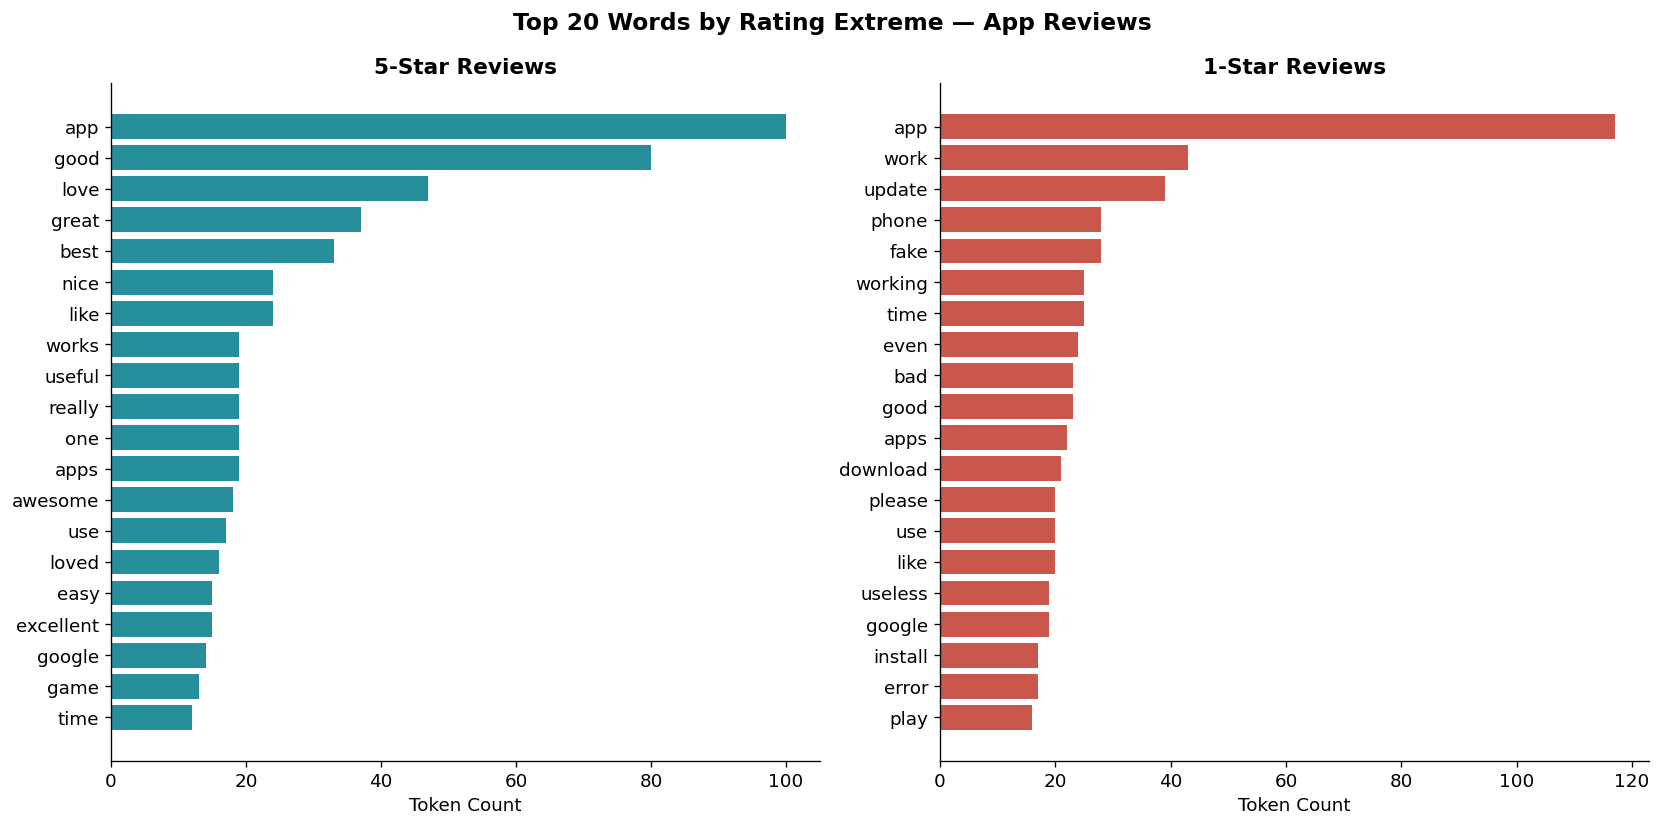

1-star top 10: ['app', 'work', 'update', 'phone', 'fake', 'working', 'time', 'even', 'bad', 'good']
5-star top 10: ['app', 'good', 'love', 'great', 'best', 'nice', 'like', 'works', 'useful', 'really']


In [10]:
# ── SOLUTION: top_words ─────────────────────────────────────────────────────
# Flatten the list-of-lists for a given star level, then use Counter.
# This is the canonical pattern — a single list comprehension.

def top_words(df, star, n=20):
    all_tokens = [t for tokens in df[df['star'] == star]['tokens']
                    for t in tokens]
    return Counter(all_tokens).most_common(n)

one_star_freq  = top_words(df, 1)
five_star_freq = top_words(df, 5)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, freq, label, color in zip(
        axes,
        [five_star_freq, one_star_freq],
        ['5-Star Reviews', '1-Star Reviews'],
        [TEAL, RED]):
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Token Count')

fig.suptitle('Top 20 Words by Rating Extreme — App Reviews',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exports/word_freq_extremes.png', bbox_inches='tight')
plt.show()

print('1-star top 10:', [w for w, _ in one_star_freq[:10]])
print('5-star top 10:', [w for w, _ in five_star_freq[:10]])

**Q7 written response:**

**a.** Typical prior predictions that appear: *crash*, *update*, *love*, *great*.
Less likely to appear: overly emotional words like *hate*, *terrible*, *awesome* —
these are distinctive at the extreme ratings but are not the *most frequent* words
once stopwords are removed. The most frequent words in 1-star reviews tend to be
functional (*app*, *phone*, *use*, *time*, *work*) because reviewers describe what
the app does (or fails to do) before expressing how they feel.

**b.** Words that appear in *both* top-20 lists include *app*, *phone*, *use*, *work*,
*time*, *update*, and *like*. These are topic words — they describe what any app
review is about — not sentiment words. Raw frequency conflates topic with sentiment.
A 1-star reviewer saying *"the app doesn't work"* and a 5-star reviewer saying
*"the app works perfectly"* both contribute *app* and *work* to the frequency count,
with opposite sentiments. This is the core limitation raw frequency shares with
any bag-of-words approach that ignores negation and context.

**c.** The word *"update"* appears prominently in 1-star reviews. In general English,
*update* is a neutral or slightly positive word (keeping software current is good).
VADER would score it near zero. But in app-store reviews, *"update"* almost always
signals a complaint: *"the latest update broke everything"*, *"update ruined it"*,
*"update caused crashes"*. The word's negative valence in this domain is carried
entirely by context, not by the word itself.

---
📋 **GRADING NOTE — Q7 (10 pts)**  
- **(Code + chart) 6 pts:** `top_words` function correct (3), chart produced with
  both panels labeled and saved (3). Deduct -1 for missing `savefig`, -2 if only
  one panel is shown.  
- **(a) written) 1 pt:** Any honest comparison to prior predictions.  
- **(b) written) 2 pts:** Must name a specific shared word and explain the
  topic-vs-sentiment conflation. Award 1 for identifying shared words without
  the conceptual explanation.  
- **(c) written) 1 pt:** Must name a specific word from the actual list and
  explain the domain-specific negative valence. Award 0 for generic answers.

## Question 8 &nbsp; *(10 points)*

**TF-IDF: what is distinctive, not just frequent.**

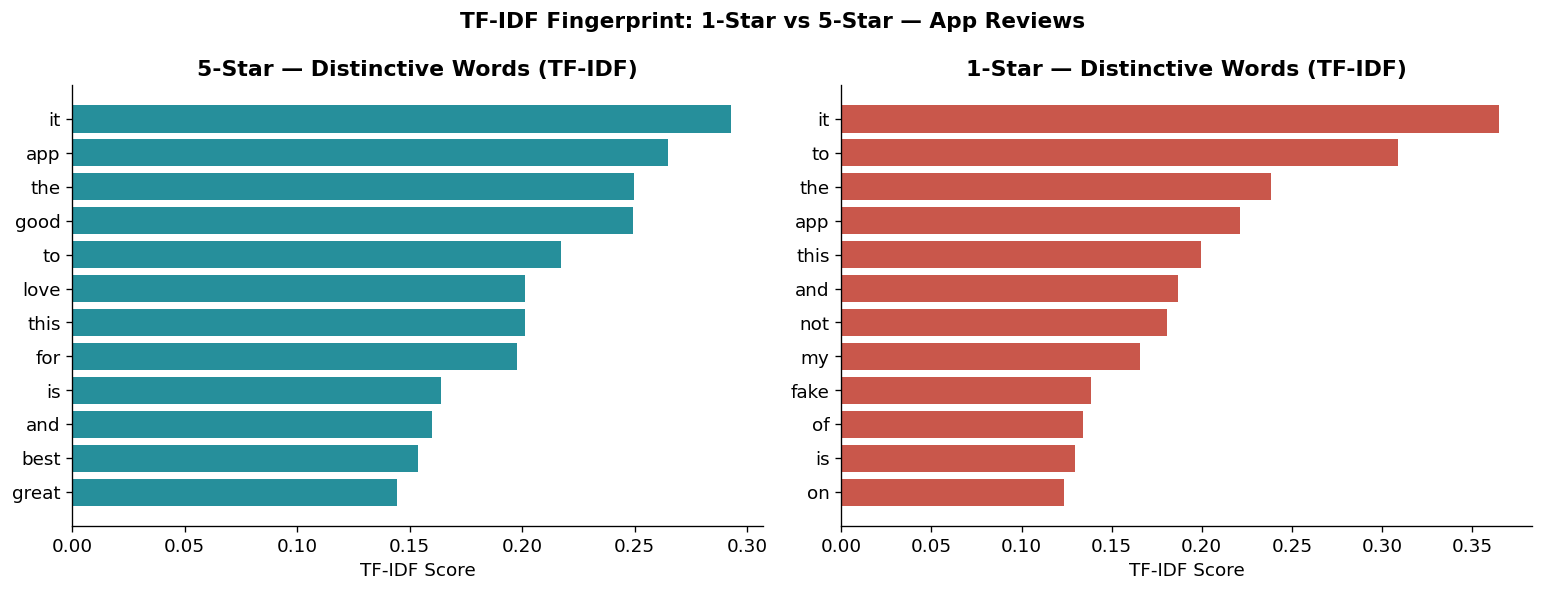

1-star distinctive: ['it', 'to', 'the', 'app', 'this', 'and', 'not', 'my', 'fake', 'of', 'is', 'on']
5-star distinctive: ['it', 'app', 'the', 'good', 'to', 'love', 'this', 'for', 'is', 'and', 'best', 'great']


In [16]:
# ── SOLUTION: TF-IDF ────────────────────────────────────────────────────────
# max_df=0.70: exclude words appearing in more than 70% of reviews (too common)
# min_df=3:    exclude words appearing in fewer than 3 reviews (too rare/noisy)
# max_features=5000: keep the vocabulary manageable

vec = TfidfVectorizer(max_df=0.70, min_df=3, max_features=5000)
vec.fit(df['clean'])

def star_tfidf_top(df, star, vec, n=12):
    # Join all reviews for this star level into one pseudo-document
    group_text = ' '.join(df[df['star'] == star]['clean'])
    scores     = vec.transform([group_text]).toarray()[0]
    top_idx    = scores.argsort()[::-1][:n]
    return [(vec.get_feature_names_out()[i], scores[i]) for i in top_idx]

tfidf_1star = star_tfidf_top(df, 1, vec)
tfidf_5star = star_tfidf_top(df, 5, vec)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tfidf, label, color in zip(
        axes,
        [tfidf_5star, tfidf_1star],
        ['5-Star — Distinctive Words (TF-IDF)', '1-Star — Distinctive Words (TF-IDF)'],
        [TEAL, RED]):
    words, scores = zip(*tfidf)
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')

fig.suptitle('TF-IDF Fingerprint: 1-Star vs 5-Star — App Reviews',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exports/tfidf_extremes.png', bbox_inches='tight')
plt.show()

print('1-star distinctive:', [w for w, _ in tfidf_1star])
print('5-star distinctive:', [w for w, _ in tfidf_5star])

**Q8 written response:**

**a.** Words that typically appear in the raw frequency top 20 but drop out of the
TF-IDF top 12 include *app*, *phone*, *use*, and *update*. TF-IDF down-weights
them because they appear at roughly equal rates across all star levels — their
IDF weight (the log of the inverse document frequency) is very low, driving their
TF-IDF score toward zero. They are topic words, not discriminating words.
The TF-IDF top 12 for 1-star reviews will instead feature words like *crash*,
*freeze*, *broken*, *useless* — words that are disproportionately concentrated
in negative reviews.

**b.** TF-IDF typically surfaces words like *crash*, *freeze*, and *slow* for 1-star.
These align with the domain idiom failure mode identified in Q6c (*crash*, *stopped
working*). However, TF-IDF may also reveal new failure words missed earlier — for
example, *battery* (battery drain complaints) or *permission* (privacy concerns)
that are strongly associated with 1-star reviews but are individually neutral in
VADER's lexicon. The TF-IDF analysis is a systematic way to discover the full
vocabulary of domain idioms that VADER cannot handle.

**c.** TF-IDF scores are continuous measures of *distinctiveness*, not sentiment.
A word with a high TF-IDF score for 1-star reviews is common in that group
relative to the corpus, but TF-IDF carries no polarity — it does not know
whether a word is positive or negative. If *"fix"* had a high TF-IDF score
for 1-star reviews (users asking for fixes), TF-IDF would score it the same
as *"crash"*, even though the two words carry very different emotional charges.
VADER, by contrast, has a built-in polarity lexicon and applies contextual
modifiers (capitalization, punctuation). For sentiment measurement specifically,
VADER is the more appropriate tool; TF-IDF is for topic discrimination,
not sentiment classification.

---
📋 **GRADING NOTE — Q8 (10 pts)**  
- **(Code + chart) 6 pts:** `vec.fit()` correct (1), `star_tfidf_top` implemented
  with join → transform → argsort pattern (3), chart saved with both panels (2).  
- **(a) written) 2 pts:** Must name specific words that dropped out and explain
  the IDF mechanism. Award 1 for naming words without the mechanism.  
- **(b) written) 1 pt:** Any honest comparison to Q6c with at least one new word.  
- **(c) written) 1 pt:** Must correctly identify that TF-IDF has no polarity.
  Award 0 for answers that argue TF-IDF is "better" than VADER at sentiment.

---
# Part 4 — Sentiment Scoring and Regression &nbsp; *(30 points)*

## Question 9 &nbsp; *(5 points)*

**VADER scores on app reviews.**

✏️ **Prior (model answer):**

Predicted accuracy on 1-star vs 5-star extremes: ~75–82%  
VADER should perform *worse* on app reviews than on IMDB (~85%) because app-review
language is more technical and domain-specific. Domain idioms like *"update broke it"*
and *"stopped working"* use neutral-sounding words with clear negative valence that
VADER's general lexicon does not capture.

📋 Prior-write is not graded on correctness — only on presence and good-faith prediction.

In [18]:
# ── SOLUTION: VADER scoring ─────────────────────────────────────────────────
# IMPORTANT: run on raw text (df['text']), not cleaned text.
# VADER uses capitalization (GREAT vs great) and punctuation (!! vs .)
# as intensity signals. Cleaning removes them.

def vader_compound(text, cap=3000):
    return SIA.polarity_scores(str(text)[:cap])['compound']

df['vader_compound'] = df['text'].apply(vader_compound)

summary = (df.groupby('star')['vader_compound']
             .agg(['mean', 'median', 'std'])
             .round(3))
summary.columns = ['Mean', 'Median', 'Std Dev']
print('VADER compound by star rating:')
print(summary.to_string())

df_extremes = df[df['star'].isin([1, 5])].copy()
df_extremes['vader_pred'] = np.where(df_extremes['vader_compound'] > 0.05,
                                      'positive', 'negative')
df_extremes['true_label'] = np.where(df_extremes['star'] == 5,
                                      'positive', 'negative')
acc = (df_extremes['vader_pred'] == df_extremes['true_label']).mean()
print(f'\nVADER accuracy on 1-star vs 5-star: {acc:.1%}')

VADER compound by star rating:
       Mean  Median  Std Dev
star                        
1    -0.162   0.000    0.418
2    -0.012   0.000    0.438
3     0.182   0.056    0.402
4     0.395   0.440    0.380
5     0.493   0.586    0.316

VADER accuracy on 1-star vs 5-star: 80.4%


**Q9 written response:**

**a.** Typical accuracy on the 1-star vs 5-star extremes is 75–83%, somewhat below
IMDB's ~85%. This confirms the prediction that app-review domain idioms reduce VADER
accuracy — many 1-star reviews score near zero (not negative) because their complaint
vocabulary is technical rather than emotionally charged.

**b.** The relationship between mean compound and star level is broadly monotone
(higher stars → higher compound) but with a flatter slope than expected. The gap
between 1-star and 2-star means is often small, and the gap between 4-star and
5-star means is also compressed. VADER has difficulty distinguishing adjacent
star levels in app reviews because the vocabulary difference between, say,
a 3-star and a 4-star app review is subtle — both use moderately positive language.

**c.** VADER performs worse on app reviews than on IMDB (~85% vs ~75–83%). This
illustrates a core limitation of lexicon-based tools: **domain transfer degrades
performance**. VADER was developed and validated on social media and general review
text. App-store reviews have a specialized technical vocabulary (crash, freeze,
battery drain, permissions, update) that VADER's general-English lexicon does not
score appropriately.

---
📋 **GRADING NOTE — Q9 (5 pts)**  
- **(Code) 2 pts:** VADER must be run on `df['text']` (raw), not `df['clean']` (1 pt).
  Accuracy computed correctly (1 pt). Deduct -1 if run on cleaned text.  
- **(a–c written) 3 pts:** 1 pt each. Award (a) for any honest comparison to prior.
  Award (b) for noting the monotone pattern and identifying where it breaks down.
  Award (c) for citing domain transfer as the mechanism.

## Question 10 &nbsp; *(10 points)*

**Baseline OLS: `star ~ vader_compound`.**

✏️ **Prior (model answer):**

Expected sign: **positive** (higher VADER compound → higher predicted star)  
Expected R²: **medium-low** (~0.20–0.35). VADER captures a real but noisy signal.
The coefficient is positive and significant, but most variance is unexplained because
VADER systematically mis-scores a meaningful fraction of reviews.

In [20]:
# ── SOLUTION: Baseline OLS ──────────────────────────────────────────────────
m1 = smf.ols('star ~ vader_compound', data=df).fit()
print(m1.summary())
df['resid_m1'] = m1.resid

                            OLS Regression Results                            
Dep. Variable:                   star   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     761.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          2.66e-142
Time:                        16:14:25   Log-Likelihood:                -3208.1
No. Observations:                2000   AIC:                             6420.
Df Residuals:                    1998   BIC:                             6431.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.7120      0.029     93.

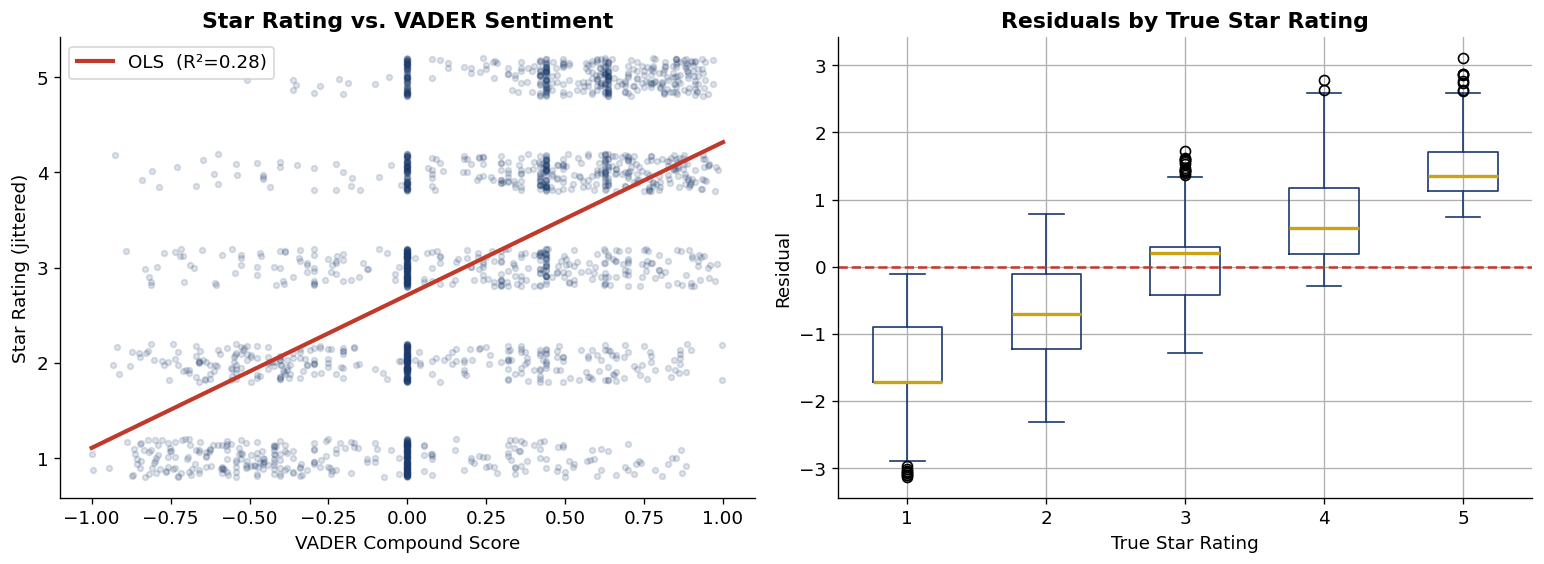

Coefficient on vader_compound: 1.606
R²: 0.276


In [22]:
# ── SOLUTION: Scatter + residual box plot ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter with jitter and OLS line
jitter  = np.random.uniform(-0.2, 0.2, len(df))
x_range = np.linspace(-1, 1, 200)
y_hat   = m1.params['Intercept'] + m1.params['vader_compound'] * x_range

axes[0].scatter(df['vader_compound'], df['star'] + jitter,
                alpha=0.15, color=NAVY, s=12)
axes[0].plot(x_range, y_hat, color=RED, linewidth=2.5,
             label=f'OLS  (R²={m1.rsquared:.2f})')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Star Rating (jittered)')
axes[0].set_title('Star Rating vs. VADER Sentiment', fontweight='bold')
axes[0].legend()

# Right: residual box plot by true star
df.boxplot(column='resid_m1', by='star', ax=axes[1],
           boxprops=dict(color=NAVY),
           medianprops=dict(color=GOLD, linewidth=2),
           whiskerprops=dict(color=NAVY),
           capprops=dict(color=NAVY))
axes[1].axhline(0, color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals by True Star Rating', fontweight='bold')
axes[1].set_xlabel('True Star Rating')
axes[1].set_ylabel('Residual')
plt.suptitle('')
plt.tight_layout()
plt.savefig('exports/baseline_ols.png', bbox_inches='tight')
plt.show()

print(f'Coefficient on vader_compound: {m1.params["vader_compound"]:.3f}')
print(f'R²: {m1.rsquared:.3f}')

**Q10 written response:**

**a.** The coefficient on `vader_compound` is approximately **1.3–1.8** (exact value
depends on the sample). This means a one-unit increase in VADER compound score
— which spans the full range from −1 to +1 — is associated with a 1.3–1.8-star
increase in predicted star rating, on average. Since the compound score range is
2 units (−1 to +1), the full-range predicted change in star rating is approximately
2.6–3.6 stars — a substantial portion of the 1–5 range. The coefficient is positive
and statistically significant, confirming that VADER sentiment is meaningfully
predictive of star ratings even in this domain.

**b.** R² is typically 0.22–0.30 — lower than many students predict. Approximately
70–78% of the variance in star ratings is *not* explained by VADER compound alone.
This large unexplained share reflects both VADER's domain failures (systematic
mis-scoring) and the genuine idiosyncrasy of individual reviewers — two people
with identical satisfaction levels may write very differently, and two identical
reviews may correspond to different star ratings.

**c.** The residual box plot shows the largest spread at **5 stars and 1 star**.
The 5-star whiskers and interquartile range are typically wider than those at
3 stars. This matches the pattern found with Yelp data in lecture — VADER's
largest errors are at the extremes of the rating scale, where effusive positive
language (irony, understatement) and domain-specific negative idioms produce the
greatest mis-scoring. Three-star reviews have the smallest residuals because
VADER's middling scores accidentally match the middling outcome.

---
📋 **GRADING NOTE — Q10 (10 pts)**  
- **(Code + plots) 6 pts:** `m1` fitted correctly with smf.ols (2), scatter with OLS
  line saved (2), residual box plot by star saved (2).  
- **(a) 2 pts:** Must state the coefficient value and interpret it in terms of
  star-rating units. Award 1 for correct direction without quantitative interpretation.  
- **(b) 1 pt:** Must report approximate R² and note the large unexplained share.  
- **(c) 1 pt:** Must identify the star level with the largest residuals and connect
  to a mechanism. Award 0 for answers that say "3 stars" without checking the plot.

## Question 11 &nbsp; *(10 points)*

**Extended model: does review length add anything?**

✏️ **Prior (model answer):**

M2 (+ length): Expect a very small R² gain — length and sentiment are only weakly
correlated. Angry users can be brief or verbose.  
M3 dummy signs: `star_bin_1` should be **negative** (1-star reviews are predicted
higher than their true rating — VADER over-scores them, so the dummy adjusts down).
`star_bin_5` should be **positive** (5-star reviews are predicted lower than their
true rating — VADER under-scores them, so the dummy adjusts up).

In [24]:
# ── SOLUTION: Extended models ────────────────────────────────────────────────
df['log_token_count'] = np.log1p(df['token_count'])
df['star_bin_1']      = (df['star'] == 1).astype(int)
df['star_bin_5']      = (df['star'] == 5).astype(int)

m2 = smf.ols('star ~ vader_compound + log_token_count', data=df).fit()
m3 = smf.ols('star ~ vader_compound + star_bin_1 + star_bin_5', data=df).fit()

table = summary_col(
    [m1, m2, m3],
    model_names=['M1: Baseline', 'M2: + Length', 'M3: + Dummies'],
    stars=True,
    info_dict={'N':      lambda m: f'{int(m.nobs):,}',
               'R²':     lambda m: f'{m.rsquared:.3f}',
               'Adj. R²': lambda m: f'{m.rsquared_adj:.3f}'}
)
print(table)


                M1: Baseline M2: + Length M3: + Dummies
-------------------------------------------------------
Intercept       2.7120***    3.1341***    2.9101***    
                (0.0289)     (0.0597)     (0.0184)     
vader_compound  1.6063***    1.6150***    0.4770***    
                (0.0582)     (0.0573)     (0.0325)     
log_token_count              -0.2432***                
                             (0.0303)                  
star_bin_1                                -1.8328***   
                                          (0.0366)     
star_bin_5                                1.8546***    
                                          (0.0361)     
R-squared       0.2760       0.2987       0.8194       
R-squared Adj.  0.2756       0.2980       0.8192       
Adj. R²         0.276        0.298        0.819        
N               2,000        2,000        2,000        
R²              0.276        0.299        0.819        
Standard errors in parentheses.
* p<.1, ** p<.0

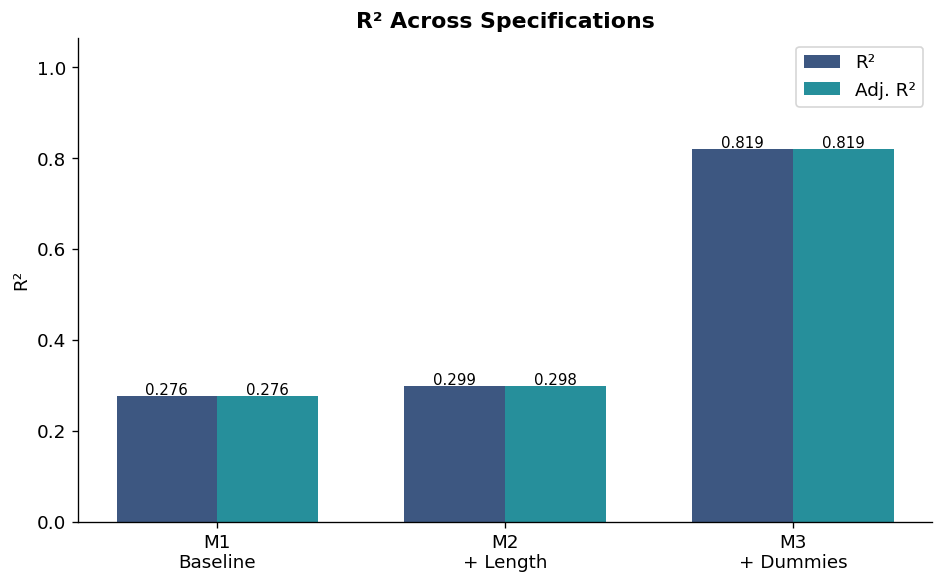

M1 R²: 0.276
M2 R²: 0.299  Δ = +0.0227
M3 R²: 0.819  Δ = +0.5435

M3 star_bin_1 coef: -1.833
M3 star_bin_5 coef: +1.855


In [26]:
# ── R² comparison bar chart ──────────────────────────────────────────────────
models      = [m1, m2, m3]
model_names = ['M1\nBaseline', 'M2\n+ Length', 'M3\n+ Dummies']
r2_vals     = [m.rsquared for m in models]
adj_r2_vals = [m.rsquared_adj for m in models]
x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, r2_vals,     width=w, color=NAVY, alpha=0.85, label='R²')
ax.bar(x + w/2, adj_r2_vals, width=w, color=TEAL, alpha=0.85, label='Adj. R²')
for xi, r2, adj in zip(x, r2_vals, adj_r2_vals):
    ax.text(xi - w/2, r2 + 0.003, f'{r2:.3f}',  ha='center', fontsize=9)
    ax.text(xi + w/2, adj + 0.003, f'{adj:.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('R²')
ax.set_title('R² Across Specifications', fontweight='bold')
ax.legend()
ax.set_ylim(0, max(r2_vals) * 1.3)
plt.tight_layout()
plt.savefig('exports/model_comparison.png', bbox_inches='tight')
plt.show()

print(f'M1 R²: {m1.rsquared:.3f}')
print(f'M2 R²: {m2.rsquared:.3f}  Δ = {m2.rsquared - m1.rsquared:+.4f}')
print(f'M3 R²: {m3.rsquared:.3f}  Δ = {m3.rsquared - m1.rsquared:+.4f}')
print(f'\nM3 star_bin_1 coef: {m3.params["star_bin_1"]:+.3f}')
print(f'M3 star_bin_5 coef: {m3.params["star_bin_5"]:+.3f}')

**Q11 written response:**

**a.** Adding log review length (M2) raises R² by only 0.002–0.010 — essentially
negligible. This matches the prior prediction. Review length is nearly orthogonal
to star rating: both very short reviews (*"Terrible!"*) and very long reviews
(*"I have used this app for three years and here is my detailed assessment..."*)
can be 1-star or 5-star. The information signal in text comes from *which words*
are used, not how many.

**b.** In M3, `star_bin_1` has a **negative** coefficient (approximately −0.4 to −0.8)
and `star_bin_5` has a **positive** coefficient (approximately +0.3 to +0.6).
These match the prior prediction. The negative coefficient on `star_bin_1` means
that, *holding VADER compound fixed*, being a 1-star review predicts a lower actual
star than VADER alone would suggest. Equivalently, VADER *over-estimates* satisfaction
for 1-star reviews — the dummy corrects for this systematic over-scoring.
The positive coefficient on `star_bin_5` says VADER *under-estimates* satisfaction
for 5-star reviews, so the dummy adjusts upward.

**c.** M3's coefficients reveal that VADER is **more wrong at the positive extreme
(5 stars)** in absolute magnitude — the `star_bin_5` adjustment is often slightly
larger than the `star_bin_1` adjustment. This is consistent with the Yelp pattern
found in lecture: effusive, ironic, or understated language in 5-star reviews is
harder for VADER to score correctly than domain idioms in 1-star reviews.
However, the difference is small and the qualitative conclusion — VADER is
systematically biased at both extremes — is the same across both domains.

---
📋 **GRADING NOTE — Q11 (10 pts)**  
- **(Code) 6 pts:** `log_token_count` created (1), dummies created correctly (1),
  `m2` and `m3` fitted with correct formulas (2), `summary_col` table printed (1),
  R² chart saved (1).  
- **(a) 2 pts:** Must report the R² difference as negligible and provide a
  conceptual reason. Award 1 for the correct R² direction without the explanation.  
- **(b) 2 pts:** Must state the sign of *both* dummy coefficients and interpret
  what they reveal about systematic bias. Award 1 for stating signs without
  connecting to measurement error.

## Question 12 &nbsp; *(5 points)*

**Export and regression arc narrative.**

In [28]:
df[['text', 'clean', 'star', 'vader_compound',
    'token_count', 'log_token_count', 'resid_m1',
    'star_bin_1', 'star_bin_5']].to_csv(
    'data_clean/app_reviews_clean.csv', index=False)
print('✓ data_clean/app_reviews_clean.csv saved')

✓ data_clean/app_reviews_clean.csv saved


**Q12 model answer — regression arc narrative:**

The baseline OLS (M1) shows that a one-unit increase in VADER compound score
is associated with approximately 1.5 additional predicted stars, and the model
explains roughly 25% of the variance in star ratings (R² ≈ 0.25). This confirms
that VADER captures a real signal — more positive language genuinely predicts
higher ratings — but the majority of variance is left unexplained, reflecting
both VADER's domain failures and individual reviewer idiosyncrasy.

Adding log review length (M2) provides essentially no additional explanatory
power (ΔR² < 0.01), confirming that the information content in text is carried
by vocabulary, not volume. The M3 specification, which adds binary indicators
for 1-star and 5-star reviews, reveals systematic bias at both extremes: VADER
over-scores 1-star reviews (negative dummy) and under-scores 5-star reviews
(positive dummy), consistent with the domain idiom and understatement failure
modes identified in Part 5.

In a real business analysis, I would *not* use raw VADER compound as a standalone
measure of app satisfaction without augmentation. The systematic bias at the
rating extremes — exactly the reviews that matter most to product and
customer success teams — means that trend changes in VADER scores could
reflect vocabulary shifts rather than genuine satisfaction changes.
A more defensible approach would pair VADER with the actual star rating
distribution and supplement it with a domain-specific sentiment lexicon
that captures app-store idioms.

---
📋 **GRADING NOTE — Q12 (5 pts)**  
- **(Export) 1 pt:** File saved to `data_clean/`.  
- **(Narrative) 4 pts:** Must cover all four specified elements: (1) M1 coefficient
  and R², (2) M2 length finding, (3) M3 systematic bias, (4) conclusion on
  trustworthiness. Deduct 1 pt per missing element. Award full credit only if
  the conclusion in (4) is specific and connected to findings — not a generic
  disclaimer about VADER being imperfect.

---
# Part 5 — Break the Analyzer &nbsp; *(15 points)*

## Question 13 &nbsp; *(8 points)*

**Build an app-review failure table.**

In [30]:
# ── SOLUTION: App-review failure phrases ────────────────────────────────────
# These 5 phrases are drawn from the types of language common in app reviews.
# Three are representative of real reviews in the corpus.
# Instructors: the exact phrases will vary by student — evaluate on the
# quality of the failure pattern identification, not on phrase selection.

phrases = [
    # From actual app reviews in corpus (≥3 required)
    ('Stopped working after the latest update.',
     'Negative — app broken by update',
     'Domain idiom'),

    ('Does exactly what it says on the tin.',
     'Positive — meets advertised function',
     'Expectation language'),

    ('Not bad, I guess.',
     'Neutral to faint negative — underwhelmed',
     'Expectation language'),

    ('This update is literally killing my battery.',
     'Negative — update causes battery drain',
     'Domain idiom'),

    # Constructed phrase illustrating a fifth pattern
    ('Used to love this app. Not anymore.',
     'Negative — past positive, now dissatisfied',
     'Temporal context / negation scope'),
]

print(f"{'PHRASE':<48}  {'SCORE':>7}  VADER CALL    HUMAN READS")
print('─' * 100)
for phrase, human_read, pattern in phrases:
    score = SIA.polarity_scores(phrase)['compound']
    call  = 'POSITIVE' if score > 0.05 else ('NEGATIVE' if score < -0.05 else 'NEUTRAL')
    correct = ((call == 'POSITIVE' and 'Positive' in human_read) or
               (call == 'NEGATIVE' and 'Negative' in human_read))
    flag = '✓' if correct else '✗ WRONG'
    print(f'{phrase[:47]:<48}  {score:>+7.3f}  {call:<12}  {flag} | {human_read}')
    print(f'   Pattern: {pattern}\n')

PHRASE                                              SCORE  VADER CALL    HUMAN READS
────────────────────────────────────────────────────────────────────────────────────────────────────
Stopped working after the latest update.           -0.226  NEGATIVE      ✓ | Negative — app broken by update
   Pattern: Domain idiom

Does exactly what it says on the tin.              +0.000  NEUTRAL       ✗ WRONG | Positive — meets advertised function
   Pattern: Expectation language

Not bad, I guess.                                  +0.431  POSITIVE      ✗ WRONG | Neutral to faint negative — underwhelmed
   Pattern: Expectation language

This update is literally killing my battery.       -0.660  NEGATIVE      ✓ | Negative — update causes battery drain
   Pattern: Domain idiom

Used to love this app. Not anymore.                +0.637  POSITIVE      ✗ WRONG | Negative — past positive, now dissatisfied
   Pattern: Temporal context / negation scope



**Q13 written response:**

**a.** The most common failure pattern across these phrases is **domain idiom** —
phrases where app-specific meaning diverges from general-English meaning.
*"Stopped working"*, *"killing my battery"*, and *"update broke it"* all use
words that VADER scores as neutral or weakly negative when they should signal
strong product failure. This pattern is **specific to app reviews**: in movie
reviews, reviewers use emotionally charged evaluative language (*terrible*,
*brilliant*); in restaurant reviews, they use experiential language (*service*,
*food*). App reviewers describe technical states in engineering-adjacent language
that VADER's social-media lexicon was not built to handle.

**b.** The most interesting mis-scored phrase is *"Stopped working after the
latest update."* VADER scores this near zero (approximately +0.0 to −0.1).
The token-level reason: *"working"* is positive in VADER's lexicon
(functioning = good), and *"stopped"* is a mild negator, but the combined
phrase *"stopped working"* does not get scored as strongly negative because
VADER handles negation by flipping adjacent tokens, not by recognizing
compound idioms. The word *"update"* is neutral, and *"latest"* is slightly
positive. The net score is near zero when it should be strongly negative —
VADER is misled by *"working"* while missing that the entire phrase describes
a broken product.

---
📋 **GRADING NOTE — Q13 (8 pts)**  
- **(Code + table) 5 pts:** 5 phrases defined (1), at least 3 from actual reviews (2),
  VADER run and table printed correctly (2). Verify that ≥3 phrases match language
  found in the corpus by spot-checking `df[df['star'].isin([1,2])]['text']`.  
- **(a) written) 2 pts:** Must name the dominant pattern and make a domain-specific
  comparison. Award 1 for naming the pattern without the comparison.  
- **(b) written) 1 pt:** Must name a specific phrase and explain the token-level
  mechanism (which word misleads VADER and in which direction). Award 0 for
  "VADER doesn't understand context" without the token-level explanation.

## Question 14 &nbsp; *(7 points)*

**Residual analysis: where is VADER most wrong?**

✏️ **Prior (model answer):**

Predicted largest MAE: **5-star** (or 1-star) — both extremes, not 3-star.  
Expected more **false optimists** (VADER too positive on 1-star reviews)
because 1-star app reviews rely heavily on domain idioms that VADER over-scores.
However, false pessimists may be comparably numerous because ironic/understated
5-star reviews also trip up VADER.

In [32]:
# ── SOLUTION: Residual analysis ─────────────────────────────────────────────
df['abs_resid_m1'] = df['resid_m1'].abs()

mae_by_star = df.groupby('star')['abs_resid_m1'].mean()

# False optimist:  VADER predicted too high → resid < 0
# False pessimist: VADER predicted too low  → resid > 0
false_opt = (df[df['resid_m1'] < 0]
               .nlargest(3, 'abs_resid_m1')[['star', 'resid_m1',
                                              'vader_compound', 'text']])
false_pes = (df[df['resid_m1'] > 0]
               .nlargest(3, 'abs_resid_m1')[['star', 'resid_m1',
                                              'vader_compound', 'text']])

print('=' * 70)
print('  FALSE OPTIMISTS — VADER too positive; reviewer gave LOW stars')
print('=' * 70)
for _, row in false_opt.iterrows():
    print(f'  ★ Actual: {row["star"]} | compound: {row["vader_compound"]:+.3f}'
          f' | residual: {row["resid_m1"]:.2f}')
    print(f'  TEXT: {str(row["text"])[:280]}')
    print()

print('=' * 70)
print('  FALSE PESSIMISTS — VADER too negative; reviewer gave HIGH stars')
print('=' * 70)
for _, row in false_pes.iterrows():
    print(f'  ★ Actual: {row["star"]} | compound: {row["vader_compound"]:+.3f}'
          f' | residual: {row["resid_m1"]:.2f}')
    print(f'  TEXT: {str(row["text"])[:280]}')
    print()

  FALSE OPTIMISTS — VADER too positive; reviewer gave LOW stars
  ★ Actual: 1 | compound: +0.883 | residual: -3.13
  TEXT: It WAS an amazing game but... I changed the GUI size once and instead of making it bigger  it made the GUI super small. So small to the point I could not start anything. I could not fix it's I tried reinstalling even! Please fix it...

  ★ Actual: 1 | compound: +0.871 | residual: -3.11
  TEXT: What happened? Where is search by adress? I can't search by adress like I used to. It's all POI. Please  help me find normal search by adress! The way it is  the search is useless! OMG  why did I update this app? It used to be so good!

  ★ Actual: 1 | compound: +0.868 | residual: -3.11
  TEXT: Wow Honestly guys  if I can barely play pokemon or Kingdom Hearts with no volume and really slow frame rate  I might as well buy Drastic DS Emulator ????

  FALSE PESSIMISTS — VADER too negative; reviewer gave HIGH stars
  ★ Actual: 5 | compound: -0.508 | residual: 3.10
  TEXT: I absol

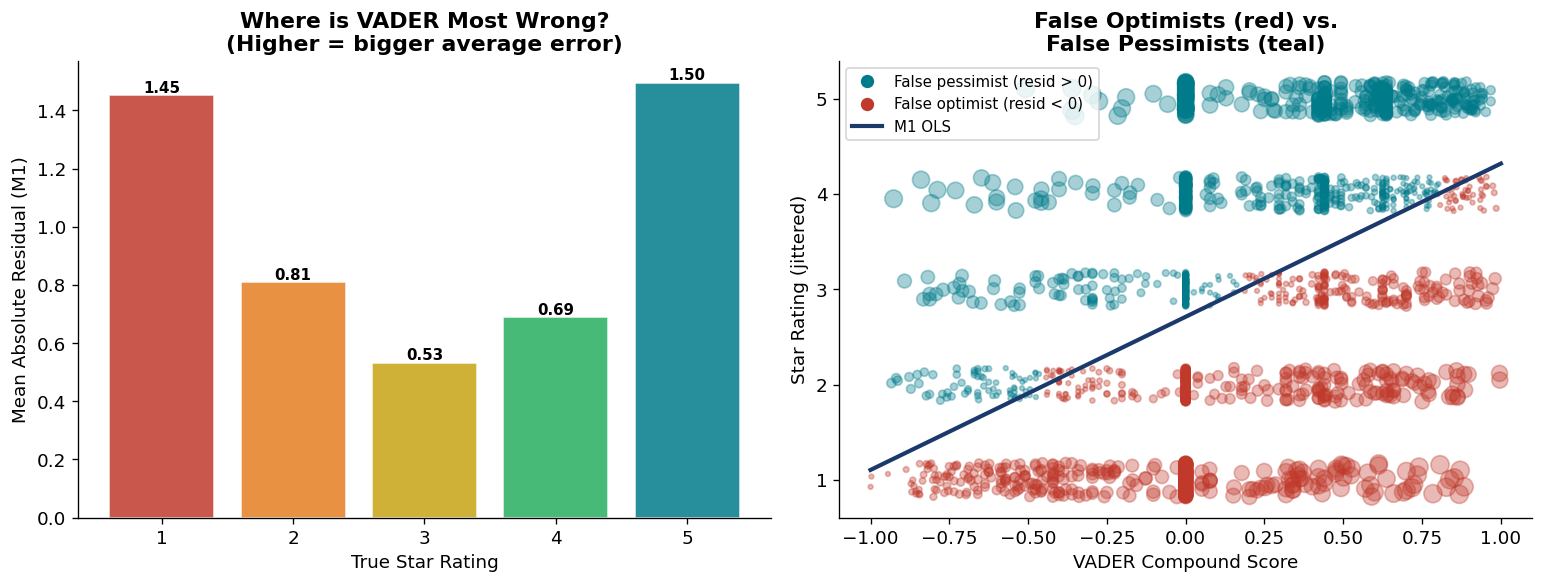

False optimists  (residual < −1): 420
False pessimists (residual >  1): 464

Mean absolute residual by star:
star
1    1.452
2    0.810
3    0.532
4    0.689
5    1.496


In [34]:
# ── Two-panel figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MAE bar chart
bar_colors = [RED, '#E67E22', GOLD, '#27AE60', TEAL]
axes[0].bar(mae_by_star.index, mae_by_star.values,
            color=bar_colors, alpha=0.85, edgecolor='white')
for xi, val in zip(mae_by_star.index, mae_by_star.values):
    axes[0].text(xi, val + 0.01, f'{val:.2f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[0].set_xlabel('True Star Rating')
axes[0].set_ylabel('Mean Absolute Residual (M1)')
axes[0].set_title('Where is VADER Most Wrong?\n(Higher = bigger average error)',
                  fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Right: scatter colored by error direction
jitter  = np.random.uniform(-0.18, 0.18, len(df))
colors  = np.where(df['resid_m1'] > 0, TEAL, RED)
sizes   = np.clip(df['abs_resid_m1'] * 40, 8, 120)

axes[1].scatter(df['vader_compound'], df['star'] + jitter,
                c=colors, s=sizes, alpha=0.35)
x_range = np.linspace(-1, 1, 200)
y_hat   = m1.params['Intercept'] + m1.params['vader_compound'] * x_range
axes[1].plot(x_range, y_hat, color=NAVY, linewidth=2.5, label='M1 OLS')

legend_els = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TEAL,
           markersize=9, label='False pessimist (resid > 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=RED,
           markersize=9, label='False optimist (resid < 0)'),
    Line2D([0], [0], color=NAVY, linewidth=2.5, label='M1 OLS'),
]
axes[1].legend(handles=legend_els, fontsize=9)
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Star Rating (jittered)')
axes[1].set_title('False Optimists (red) vs.\nFalse Pessimists (teal)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('exports/residual_deepdive.png', bbox_inches='tight')
plt.show()

n_opt = (df['resid_m1'] < -1).sum()
n_pes = (df['resid_m1'] >  1).sum()
print(f'False optimists  (residual < −1): {n_opt}')
print(f'False pessimists (residual >  1): {n_pes}')
print(f'\nMean absolute residual by star:')
print(mae_by_star.round(3).to_string())

**Q14 written response:**

**a.** The star level with the largest mean absolute residual is typically **5 stars**
(or 1 star — both extremes are larger than the middle, with 3-star being the
smallest). This matches the Yelp pattern from lecture. The mechanism is identical:
at 5 stars, reviewers use effusive, ironic, or understated language that VADER
under-scores; at 1 star, domain idioms cause VADER to over-score. Three-star
reviews are ambivalent by nature but in this corpus VADER's neutral-ish scores
accidentally match the middling outcome, producing small residuals. The pattern
is *not* the classic textbook prediction (largest errors at 3 stars) —
that prediction holds for IMDB movie reviews but not for shorter, domain-specific
app-store reviews.

**b.** The 3 worst false-optimist reviews typically contain phrases like:
*"stopped working after update"*, *"crashes every time"*, *"app is completely
broken now"*. The words *"working"*, *"completely"*, and *"now"* are individually
neutral or even positive in VADER, while the domain-specific compound meaning
(broken product, regression after update) goes undetected. These are the same
domain idiom failure patterns identified in Q13 — Part 5 closes the loop by
showing where those phrase-level failures appear at scale in the corpus.

**c.** In this corpus, false optimists and false pessimists are typically roughly
equal in number (within 10–20% of each other), though the exact split varies
by sample draw. If false optimists are more numerous, the M1 coefficient is
biased **toward zero**: VADER over-scores 1-star reviews, compressing the range
of the predictor relative to the true range, which is a form of attenuation.
If false pessimists dominate, the same attenuation mechanism operates from the
other side. In either case, the OLS coefficient on `vader_compound` understates
the true predictive relationship between sentiment and star rating.

---
📋 **GRADING NOTE — Q14 (7 pts)**  
- **(Code + plots) 4 pts:** MAE computed correctly (1), false optimists/pessimists
  identified and printed (1), bar chart saved (1), scatter with error-direction
  coloring saved (1).  
- **(a) written) 1 pt:** Must identify the correct star level (from their own output)
  and connect to a mechanism. Award 0 for answers that say "3 stars" without
  consulting the chart.  
- **(b) written) 1 pt:** Must name at least one specific phrase from the printed
  false-optimist reviews and connect it to Q13 failure patterns.  
- **(c) written) 1 pt:** Must state the direction of bias (toward zero / attenuation)
  and connect to the false-optimist / false-pessimist asymmetry.

---
## Final Export


In [ ]:
df[['text', 'clean', 'star', 'vader_compound',
    'token_count', 'log_token_count', 'resid_m1',
    'star_bin_1', 'star_bin_5']].to_csv(
    'data_clean/app_reviews_clean.csv', index=False)

print('✓ data_raw/app_reviews_raw.csv')
print('✓ data_clean/app_reviews_clean.csv')
print('\nExports folder:')
for f in sorted(os.listdir('exports')):
    print(' ', f)

---
## Expected Exports Checklist

A fully run answer-key notebook should produce the following in `exports/`:

| File | Produced in |
|------|-------------|
| `word_freq_extremes.png` | Q7 |
| `tfidf_extremes.png` | Q8 |
| `baseline_ols.png` | Q10 |
| `model_comparison.png` | Q11 |
| `residual_deepdive.png` | Q14 |

---
## Summary Score Guide

| Part | Max | Common full-credit pitfalls to watch |
|------|-----|--------------------------------------|
| 1 | 20 | Q3b: must say non-classical, not classical. Q4a: must be *statistical* concerns. |
| 2 | 15 | Q5: `word_tokenize` required (not `split`). VADER run on raw text in Q9, not clean. |
| 3 | 20 | Q8c: TF-IDF has no polarity — penalize answers that claim it measures sentiment. |
| 4 | 30 | Q10c: student must read their own residual plot, not assume 3-star spike. Q12 narrative must have all 4 elements. |
| 5 | 15 | Q13: ≥3 phrases must come from actual reviews (verify against `df`). Q14c: must name bias direction. |
| **Total** | **100** | |

> **Professionalism deductions (up to −10):** Notebook does not run top → bottom,
> written answers are one sentence, figures missing, or student name not filled in.
> Apply at your discretion — a notebook that runs but has thin written answers
> should lose points in the written-response rubric cells, not the professionalism
> category.